In [ ]:
import pandas as pd
import os

# Folder path
folder_path = "D:\\working_projects\\AI_POWERED_NEXT_GENRTIONS_FIREWALL\\CSMSS_NGFW\\novashield_AI\\NovaShield(Final_Product)\\ai_engine\\model\\dataset"

In [4]:
# Get all CSV files
all_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

dataframes = []

for file in all_files:
    file_path = os.path.join(folder_path, file)
    print(f"Loading: {file}")
    
    df = pd.read_csv(file_path, low_memory=False)
    dataframes.append(df)

Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
Loading: Wednesday-workingHours.pcap_ISCX.csv


In [5]:
# Merge all
combined_df = pd.concat(dataframes, ignore_index=True)

print("Total rows:", combined_df.shape)

Total rows: (2830743, 79)


In [6]:
# Save merged dataset
combined_df.to_csv("dataset/combined.csv", index=False)

print("✅ Dataset merged successfully!")

✅ Dataset merged successfully!


DATASET CLENING

In [2]:
import torch
print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Is CUDA available? True
GPU Name: NVIDIA GeForce RTX 2050


In [7]:
df = pd.read_csv("dataset/combined.csv", low_memory=False)

print("Before cleaning:", df.shape)
print(df.head())

ParserError: Error tokenizing data. C error: out of memory

In [4]:
import pandas as pd
import os
import numpy as np

folder = "D:\\working_projects\\AI_POWERED_NEXT_GENRTIONS_FIREWALL\\CSMSS_NGFW\\novashield_AI\\NovaShield(Final_Product)\\ai_engine\\model\\dataset"
files = [f for f in os.listdir(folder) if f.endswith(".csv")]

all_data = []

for file in files:
    print("Processing:", file)
    
    df = pd.read_csv(os.path.join(folder, file), low_memory=False)
    
    # Clean here
    df.replace([np.inf, -np.inf], 0, inplace=True)
    df.dropna(inplace=True)
    df.columns = df.columns.str.strip()
    
    all_data.append(df)

final_df = pd.concat(all_data, ignore_index=True)

final_df.to_csv("dataset/cleaned.csv", index=False)

print("✅ Done:", final_df.shape)

Processing: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Processing: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Processing: Friday-WorkingHours-Morning.pcap_ISCX.csv
Processing: Monday-WorkingHours.pcap_ISCX.csv
Processing: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Processing: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Processing: Tuesday-WorkingHours.pcap_ISCX.csv
Processing: Wednesday-workingHours.pcap_ISCX.csv
✅ Done: (2829385, 79)


In [7]:
final_df.head()


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
import pandas as pd

df = pd.read_csv("dataset/cleaned.csv", low_memory=False)

print(df.shape)
df.head()

(2829385, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


Encode Labels

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Label'] = le.fit_transform(df['Label'])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'BENIGN': np.int64(0), 'Bot': np.int64(1), 'DDoS': np.int64(2), 'DoS GoldenEye': np.int64(3), 'DoS Hulk': np.int64(4), 'DoS Slowhttptest': np.int64(5), 'DoS slowloris': np.int64(6), 'FTP-Patator': np.int64(7), 'Heartbleed': np.int64(8), 'Infiltration': np.int64(9), 'PortScan': np.int64(10), 'SSH-Patator': np.int64(11), 'Web Attack � Brute Force': np.int64(12), 'Web Attack � Sql Injection': np.int64(13), 'Web Attack � XSS': np.int64(14)}


In [6]:
df = pd.read_csv("dataset/cleaned.csv", encoding='latin1')

In [7]:
df['Label'] = df['Label'].str.replace('�', '-')

In [8]:
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'BENIGN': np.int64(0), 'Bot': np.int64(1), 'DDoS': np.int64(2), 'DoS GoldenEye': np.int64(3), 'DoS Hulk': np.int64(4), 'DoS Slowhttptest': np.int64(5), 'DoS slowloris': np.int64(6), 'FTP-Patator': np.int64(7), 'Heartbleed': np.int64(8), 'Infiltration': np.int64(9), 'PortScan': np.int64(10), 'SSH-Patator': np.int64(11), 'Web Attack � Brute Force': np.int64(12), 'Web Attack � Sql Injection': np.int64(13), 'Web Attack � XSS': np.int64(14)}


Split Features & Target

In [9]:
X = df.drop('Label', axis=1)
y = df['Label']

Feature Scaling

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Train/Test Split

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(2263508, 78) (565877, 78)


In [17]:
from sklearn.ensemble import RandomForestClassifier

temp_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

temp_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [18]:
import pandas as pd

importance = temp_model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df.head(25))

                        Feature  Importance
39            Max Packet Length    0.063798
41            Packet Length Std    0.060552
42       Packet Length Variance    0.056238
54         Avg Bwd Segment Size    0.046723
52          Average Packet Size    0.042476
0              Destination Port    0.040439
5   Total Length of Bwd Packets    0.037846
63            Subflow Fwd Bytes    0.037371
10        Bwd Packet Length Max    0.036227
4   Total Length of Fwd Packets    0.033713
6         Fwd Packet Length Max    0.030387
65            Subflow Bwd Bytes    0.030383
66       Init_Win_bytes_forward    0.026510
34            Fwd Header Length    0.023991
13        Bwd Packet Length Std    0.020454
12       Bwd Packet Length Mean    0.020411
40           Packet Length Mean    0.020102
55          Fwd Header Length.1    0.018995
67      Init_Win_bytes_backward    0.017318
53         Avg Fwd Segment Size    0.015637
2             Total Fwd Packets    0.015568
8        Fwd Packet Length Mean 

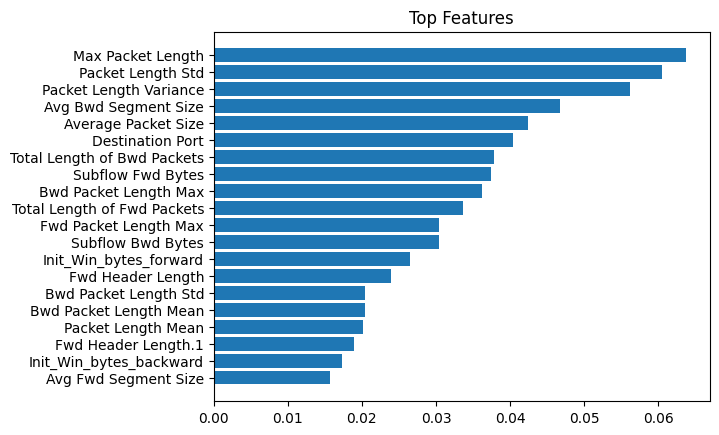

In [19]:
import matplotlib.pyplot as plt

top = importance_df.head(20)

plt.figure()
plt.barh(top['Feature'], top['Importance'])
plt.gca().invert_yaxis()
plt.title("Top Features")
plt.show()

select top 25 fetures

In [20]:
top_features = importance_df['Feature'].head(25).tolist()

In [21]:
X_reduced = X[top_features]

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

train model

In [24]:
model = RandomForestClassifier(
    n_estimators=80,   # slightly optimized
    max_depth=15,      # control size
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",80
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

model Evaluate

In [25]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9979306457056922


save model

In [28]:
import joblib

joblib.dump(model, "models/model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(top_features, "models/features.pkl")
joblib.dump(le, "models/label_encoder.pkl")

['models/label_encoder.pkl']

In [29]:
import joblib

model = joblib.load("models/model.pkl")
label_encoder = joblib.load("models/label_encoder.pkl")

print("Classes:", label_encoder.classes_)

Classes: ['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack � Brute Force' 'Web Attack � Sql Injection'
 'Web Attack � XSS']


In [ ]:
print(len(top_features))

NameError: name 'features_list' is not defined

In [1]:
from scapy.all import get_if_list
print(get_if_list())

['\\Device\\NPF_{3F79B419-3A55-4AE0-B782-E0AB823ADF16}', '\\Device\\NPF_{6FA78842-A4E0-4C1F-8707-75927ACDC099}', '\\Device\\NPF_{22E8F4F8-C393-46DC-9977-5EBA06973F7B}', '\\Device\\NPF_{89989AE1-BBC0-4F04-BBF0-91F0A4DEE6F3}', '\\Device\\NPF_{D3DB63C8-9D22-4230-90B2-0061758F8E2C}', '\\Device\\NPF_{27CDF90A-AD4C-4DB2-9457-C1BD3FB711FA}', '\\Device\\NPF_{C94A519C-5AE7-4CC2-AE7E-BD878B213E39}', '\\Device\\NPF_{CE66671C-85B9-42A9-B74D-845A0D9FE6D5}', '\\Device\\NPF_{CA010168-9FB1-4906-A172-CA2FDD63B89D}', '\\Device\\NPF_Loopback', '\\Device\\NPF_{1D0E1DA1-B8B9-4A57-9242-100C7CBCDD87}', '\\Device\\NPF_{95CB76E0-A562-4789-904E-03D59C50ACB3}']


In [2]:
from scapy.all import get_if_list, get_if_addr

interfaces = get_if_list()

for iface in interfaces:
    try:
        ip = get_if_addr(iface)
        print(f"{iface} → {ip}")
    except:
        pass

\Device\NPF_{3F79B419-3A55-4AE0-B782-E0AB823ADF16} → 0.0.0.0
\Device\NPF_{6FA78842-A4E0-4C1F-8707-75927ACDC099} → 0.0.0.0
\Device\NPF_{22E8F4F8-C393-46DC-9977-5EBA06973F7B} → 0.0.0.0
\Device\NPF_{89989AE1-BBC0-4F04-BBF0-91F0A4DEE6F3} → 169.254.190.158
\Device\NPF_{D3DB63C8-9D22-4230-90B2-0061758F8E2C} → 10.225.30.7
\Device\NPF_{27CDF90A-AD4C-4DB2-9457-C1BD3FB711FA} → 192.168.50.1
\Device\NPF_{C94A519C-5AE7-4CC2-AE7E-BD878B213E39} → 192.168.73.1
\Device\NPF_{CE66671C-85B9-42A9-B74D-845A0D9FE6D5} → 169.254.183.253
\Device\NPF_{CA010168-9FB1-4906-A172-CA2FDD63B89D} → 169.254.172.75
\Device\NPF_Loopback → 127.0.0.1
\Device\NPF_{1D0E1DA1-B8B9-4A57-9242-100C7CBCDD87} → 169.254.126.148
\Device\NPF_{95CB76E0-A562-4789-904E-03D59C50ACB3} → 169.254.224.156


## Senior IDS Training Pipeline (Appended)

This section is appended only. Existing cells above are unchanged.
It includes: data cleaning, EDA visuals, model selection, final training, evaluation, save, and prediction helper.


In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
USE_FULL_DATA = True  # Set False to run faster on a subset.
SAMPLE_ROWS = 600_000

BASE_DIR = Path.cwd()
DATASET_PATH = BASE_DIR / "dataset" / "cleaned.csv"
MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_DIR / "model.pkl"
SCALER_PATH = MODELS_DIR / "scaler.pkl"
FEATURES_PATH = MODELS_DIR / "features.pkl"
LABEL_ENCODER_PATH = MODELS_DIR / "label_encoder.pkl"

print(f"Dataset path: {DATASET_PATH}")
print(f"Models path: {MODELS_DIR}")


Dataset path: d:\working_projects\AI_POWERED_NEXT_GENRTIONS_FIREWALL\CSMSS_NGFW\novashield_AI\NovaShield_Final_Product\ai_engine\model\dataset\cleaned.csv
Models path: d:\working_projects\AI_POWERED_NEXT_GENRTIONS_FIREWALL\CSMSS_NGFW\novashield_AI\NovaShield_Final_Product\ai_engine\model\models


In [2]:
def normalize_label(text: str) -> str:
    value = str(text).strip()
    replacements = {
        "Web Attack ? Brute Force": "Web Attack - Brute Force",
        "Web Attack ??? Brute Force": "Web Attack - Brute Force",
        "Web Attack ? Brute Force": "Web Attack - Brute Force",
        "Web Attack ? Sql Injection": "Web Attack - Sql Injection",
        "Web Attack ??? Sql Injection": "Web Attack - Sql Injection",
        "Web Attack ? Sql Injection": "Web Attack - Sql Injection",
        "Web Attack ? XSS": "Web Attack - XSS",
        "Web Attack ??? XSS": "Web Attack - XSS",
        "Web Attack ? XSS": "Web Attack - XSS",
    }
    return replacements.get(value, value)

df = pd.read_csv(DATASET_PATH, low_memory=False)
df.columns = df.columns.str.strip()
df = df.replace([np.inf, -np.inf], np.nan)
df["Label"] = df["Label"].astype(str).map(normalize_label)

if not USE_FULL_DATA:
    sample_n = min(SAMPLE_ROWS, len(df))
    frac = sample_n / len(df)
    sampled_parts = []
    for _, grp in df.groupby("Label"):
        n = max(5, int(len(grp) * frac))
        n = min(n, len(grp))
        sampled_parts.append(grp.sample(n=n, random_state=RANDOM_STATE))
    df = pd.concat(sampled_parts, axis=0).sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

print("Shape:", df.shape)
print("Classes:", df["Label"].nunique())


Shape: (2829385, 79)
Classes: 15


Duplicate rows: 307376
Top 10 columns by missing ratio:
Destination Port               0.0
Flow Duration                  0.0
Total Fwd Packets              0.0
Total Backward Packets         0.0
Total Length of Fwd Packets    0.0
Total Length of Bwd Packets    0.0
Fwd Packet Length Max          0.0
Fwd Packet Length Min          0.0
Fwd Packet Length Mean         0.0
Fwd Packet Length Std          0.0
dtype: float64

Class distribution:
Label
BENIGN                        2272688
DoS Hulk                       230124
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed          

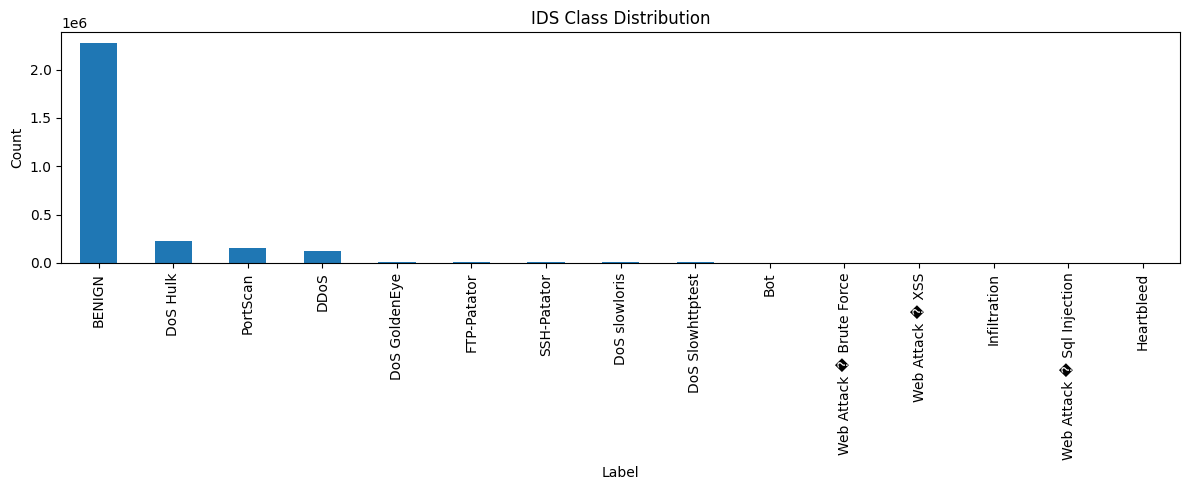

In [3]:
# Basic EDA checks
print("Duplicate rows:", int(df.duplicated().sum()))
missing_ratio = (df.isna().sum() / len(df)).sort_values(ascending=False)
print("Top 10 columns by missing ratio:")
print(missing_ratio.head(10).round(4))

label_counts = df["Label"].value_counts()
print("\nClass distribution:")
print(label_counts)

plt.figure(figsize=(12, 5))
label_counts.plot(kind="bar")
plt.title("IDS Class Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [4]:
# Feature/target split
X = df.drop(columns=["Label"]).apply(pd.to_numeric, errors="coerce")
y_text = df["Label"].astype(str)

# Keep only classes that have enough support for stable split/eval
class_counts = y_text.value_counts()
valid_classes = class_counts[class_counts >= 10].index
mask = y_text.isin(valid_classes)
X = X.loc[mask].reset_index(drop=True)
y_text = y_text.loc[mask].reset_index(drop=True)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_tmp
)

# Keep StandardScaler for runtime compatibility with existing predictor.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)


Train/Val/Test: (1980569, 78) (424408, 78) (424408, 78)


In [5]:
# Candidate model comparison (optimized for imbalanced IDS classification)
candidates = {
    "RandomForest": RandomForestClassifier(
        n_estimators=240,
        max_depth=24,
        min_samples_leaf=1,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=240,
        max_depth=24,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

results = []
for name, est in candidates.items():
    m = clone(est)
    m.fit(X_train_s, y_train)
    pred = m.predict(X_val_s)
    acc = accuracy_score(y_val, pred)
    macro_f1 = f1_score(y_val, pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_val, pred, average="weighted", zero_division=0)
    results.append((name, acc, macro_f1, weighted_f1))
    print(f"{name}: acc={acc:.4f}, macro_f1={macro_f1:.4f}, weighted_f1={weighted_f1:.4f}")

results_df = pd.DataFrame(results, columns=["model", "accuracy", "macro_f1", "weighted_f1"])
results_df = results_df.sort_values(["macro_f1", "weighted_f1", "accuracy"], ascending=False)
best_model_name = results_df.iloc[0]["model"]
print("\nSelected best model:", best_model_name)
display(results_df)


KeyboardInterrupt: 

In [ ]:
# Final training on train+val, then evaluate on test
X_trainval = np.vstack([X_train_s, X_val_s])
y_trainval = np.concatenate([y_train, y_val])

final_model = clone(candidates[best_model_name])
final_model.fit(X_trainval, y_trainval)

y_pred = final_model.predict(X_test_s)
test_acc = accuracy_score(y_test, y_pred)
test_macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
test_weighted_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Test accuracy: {test_acc:.4f}")
print(f"Test macro-F1: {test_macro_f1:.4f}")
print(f"Test weighted-F1: {test_weighted_f1:.4f}")

y_test_text = label_encoder.inverse_transform(y_test)
y_pred_text = label_encoder.inverse_transform(y_pred)
print("\nClassification report:")
print(classification_report(y_test_text, y_pred_text, zero_division=0))

labels = list(label_encoder.classes_)
cm = confusion_matrix(y_test_text, y_pred_text, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
display(cm_df)

# Feature importance (tree models)
if hasattr(final_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": X.columns,
        "importance": final_model.feature_importances_,
    }).sort_values("importance", ascending=False)
    display(importance_df.head(25))
    plt.figure(figsize=(10, 6))
    top25 = importance_df.head(25).iloc[::-1]
    plt.barh(top25["feature"], top25["importance"])
    plt.title(f"Top 25 Features - {best_model_name}")
    plt.tight_layout()
    plt.show()


In [ ]:
# Save artifacts for runtime prediction
joblib.dump(final_model, MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)
joblib.dump(list(X.columns), FEATURES_PATH)
joblib.dump(label_encoder, LABEL_ENCODER_PATH)

print("Saved artifacts:")
print(MODEL_PATH)
print(SCALER_PATH)
print(FEATURES_PATH)
print(LABEL_ENCODER_PATH)

def predict_one(feature_map: dict):
    x = pd.DataFrame([[float(feature_map.get(col, 0.0)) for col in X.columns]], columns=X.columns)
    x_s = scaler.transform(x)
    pred = final_model.predict(x_s)[0]
    return label_encoder.inverse_transform([pred])[0]

# Example: predict the first test sample
sample_features = {col: X_test.iloc[0][col] for col in X.columns}
print("Sample prediction:", predict_one(sample_features))
